<a href="https://colab.research.google.com/github/SUDEEPZ-RAM/Classification-of-speech-categories-from-1-bit-quantized-signals/blob/main/Classical%20Models/ml1BIT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/1bit_speech/features/balanced_1bit_4class.csv"
)

print(df.shape)

df.head()

(12000, 26)


,filename,digit,speaker,recording_id,mean_zcr,std_zcr,min_zcr,max_zcr,mean_pos_run,std_pos_run,...,mean_amdf_min,std_amdf_min,mean_hnr,std_hnr,mean_rhythm_change,std_rhythm_change,active_frame_ratio,longest_active_region,speech_type,label
0,0_george_0.wav,0.0,george,0.0,0.053854,0.049220,0.0000,0.1525,10.673585,8.511317,...,0.062257,0.052744,4.721815,1.933585,0.007340,0.009965,0.625000,30,numeric,NaN
1,0_george_1.wav,0.0,george,1.0,0.069792,0.025657,0.0225,0.1275,13.297258,9.672022,...,0.079456,0.028948,8.198979,2.487650,0.009149,0.009157,1.000000,48,numeric,NaN
2,0_george_10.wav,0.0,george,10.0,0.139740,0.071055,0.0425,0.2800,6.780220,7.289114,...,0.155108,0.077819,10.922898,4.691711,0.013670,0.013177,1.000000,48,numeric,NaN
3,0_george_11.wav,0.0,george,11.0,0.083281,0.046598,0.0000,0.1875,10.391727,9.095055,...,0.094402,0.051955,7.497236,1.986925,0.012660,0.010981,0.937500,45,numeric,NaN
4,0_george_12.wav,0.0,george,12.0,0.088333,0.054552,0.0200,0.1925,10.597015,10.710337,...,0.100345,0.059813,7.032383,1.480084,0.010000,0.010366,0.979167,41,numeric,NaN


In [ ]:
print(
    df["speech_type"].value_counts()
)

speech_type
numeric           3000
command           3000
read              3000
conversational    3000
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["target"] = le.fit_transform(
    df["speech_type"]
)

print(
    dict(
        zip(
            le.classes_,
            range(len(le.classes_))
        )
    )
)

{'command': 0, 'conversational': 1, 'numeric': 2, 'read': 3}


In [ ]:
remove_cols = []

for col in [
    "filepath",
    "filename",
    "speaker",
    "session",
    "command",
    "digit",
    "label",
    "speech_type",
    "target",
    "recording_id"
]:

    if col in df.columns:
        remove_cols.append(col)

X = df.drop(
    columns=remove_cols
)

y = df["target"]

print("Features Shape:", X.shape)

Features Shape: (12000, 20)


In [ ]:
print(X.columns.tolist())

['mean_zcr', 'std_zcr', 'min_zcr', 'max_zcr', 'mean_pos_run', 'std_pos_run', 'max_pos_run', 'mean_neg_run', 'std_neg_run', 'max_neg_run', 'mean_autocorr_peak', 'std_autocorr_peak', 'mean_amdf_min', 'std_amdf_min', 'mean_hnr', 'std_hnr', 'mean_rhythm_change', 'std_rhythm_change', 'active_frame_ratio', 'longest_active_region']


In [ ]:
# First split: 80 train, 20 temp

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

# Split temp into validation and test

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (9600, 20)
Validation: (1200, 20)
Test: (1200, 20)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
rf_train_pred = rf.predict(X_train)

rf_val_pred = rf.predict(X_val)

rf_test_pred = rf.predict(X_test)

rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

rf_val_acc = accuracy_score(
    y_val,
    rf_val_pred
)

rf_test_acc = accuracy_score(
    y_test,
    rf_test_pred
)

print("Train Accuracy:", rf_train_acc)
print("Validation Accuracy:", rf_val_acc)
print("Test Accuracy:", rf_test_acc)

Train Accuracy: 0.9990625
Validation Accuracy: 0.7191666666666666
Test Accuracy: 0.7091666666666666


In [ ]:
print(
    classification_report(
        y_test,
        rf_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.63      0.58      0.60       300
conversational       0.66      0.67      0.67       300
       numeric       0.91      0.93      0.92       300
          read       0.63      0.66      0.65       300

      accuracy                           0.71      1200
     macro avg       0.71      0.71      0.71      1200
  weighted avg       0.71      0.71      0.71      1200



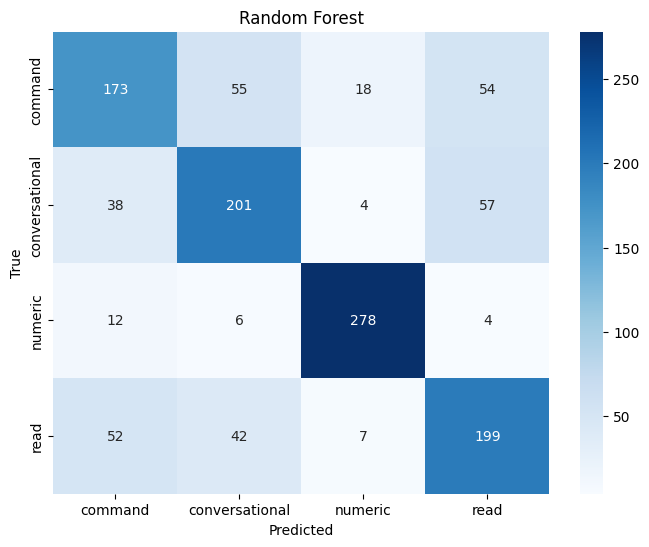

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest")

plt.show()

In [ ]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000)

In [ ]:
lr_train_pred = lr.predict(
    X_train_scaled
)

lr_val_pred = lr.predict(
    X_val_scaled
)

lr_test_pred = lr.predict(
    X_test_scaled
)

lr_train_acc = accuracy_score(
    y_train,
    lr_train_pred
)

lr_val_acc = accuracy_score(
    y_val,
    lr_val_pred
)

lr_test_acc = accuracy_score(
    y_test,
    lr_test_pred
)

print("Train Accuracy:", lr_train_acc)
print("Validation Accuracy:", lr_val_acc)
print("Test Accuracy:", lr_test_acc)

Train Accuracy: 0.5960416666666667
Validation Accuracy: 0.6025
Test Accuracy: 0.5908333333333333


In [ ]:
print(
    classification_report(
        y_test,
        lr_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.48      0.53      0.51       300
conversational       0.54      0.56      0.55       300
       numeric       0.77      0.85      0.81       300
          read       0.55      0.42      0.48       300

      accuracy                           0.59      1200
     macro avg       0.59      0.59      0.59      1200
  weighted avg       0.59      0.59      0.59      1200



In [ ]:
svm = SVC()

svm.fit(
    X_train_scaled,
    y_train
)

SVC()

In [ ]:
svm_train_pred = svm.predict(
    X_train_scaled
)

svm_val_pred = svm.predict(
    X_val_scaled
)

svm_test_pred = svm.predict(
    X_test_scaled
)

svm_train_acc = accuracy_score(
    y_train,
    svm_train_pred
)

svm_val_acc = accuracy_score(
    y_val,
    svm_val_pred
)

svm_test_acc = accuracy_score(
    y_test,
    svm_test_pred
)

print("Train Accuracy:", svm_train_acc)
print("Validation Accuracy:", svm_val_acc)
print("Test Accuracy:", svm_test_acc)

Train Accuracy: 0.7052083333333333
Validation Accuracy: 0.6775
Test Accuracy: 0.6883333333333334


In [ ]:
print(
    classification_report(
        y_test,
        svm_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.59      0.59      0.59       300
conversational       0.64      0.71      0.67       300
       numeric       0.88      0.87      0.87       300
          read       0.66      0.58      0.62       300

      accuracy                           0.69      1200
     macro avg       0.69      0.69      0.69      1200
  weighted avg       0.69      0.69      0.69      1200



In [ ]:
results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Logistic Regression",
        "SVM"
    ],

    "Train Accuracy": [
        rf_train_acc,
        lr_train_acc,
        svm_train_acc
    ],

    "Validation Accuracy": [
        rf_val_acc,
        lr_val_acc,
        svm_val_acc
    ],

    "Test Accuracy": [
        rf_test_acc,
        lr_test_acc,
        svm_test_acc
    ]
})

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Random Forest,0.999062,0.719167,0.709167
1,Logistic Regression,0.596042,0.602500,0.590833
2,SVM,0.705208,0.677500,0.688333


In [ ]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='multi:softmax',

    num_class=4,

    random_state=42,

    eval_metric='mlogloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=4, ...)

In [ ]:
xgb_train_pred = xgb.predict(X_train)

xgb_val_pred = xgb.predict(X_val)

xgb_test_pred = xgb.predict(X_test)

xgb_train_acc = accuracy_score(
    y_train,
    xgb_train_pred
)

xgb_val_acc = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_test_acc = accuracy_score(
    y_test,
    xgb_test_pred
)

print("Train Accuracy:", xgb_train_acc)
print("Validation Accuracy:", xgb_val_acc)
print("Test Accuracy:", xgb_test_acc)

Train Accuracy: 0.9285416666666667
Validation Accuracy: 0.7358333333333333
Test Accuracy: 0.7175


In [ ]:
print(
    classification_report(
        y_test,
        xgb_test_pred,
        target_names=le.classes_
    )
)

                precision    recall  f1-score   support

       command       0.64      0.58      0.61       300
conversational       0.69      0.70      0.69       300
       numeric       0.88      0.92      0.90       300
          read       0.65      0.67      0.66       300

      accuracy                           0.72      1200
     macro avg       0.71      0.72      0.72      1200
  weighted avg       0.71      0.72      0.72      1200



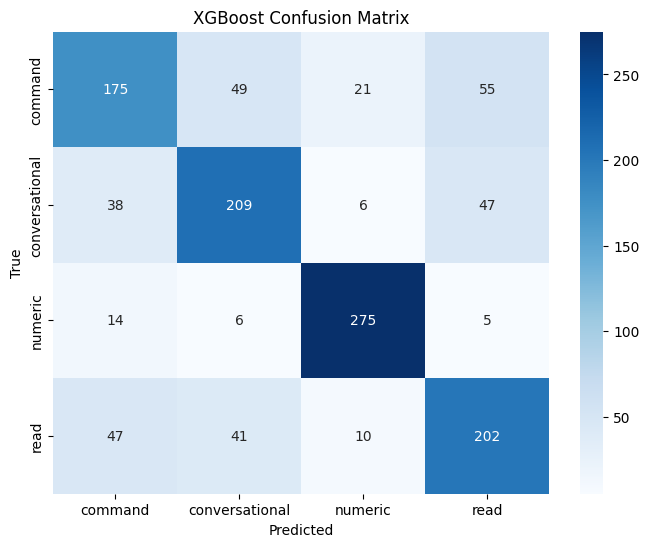

In [ ]:
cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(
    y_test,
    xgb_test_pred
)

class_acc = cm.diagonal() / cm.sum(axis=1)

for cls, acc in zip(
    le.classes_,
    class_acc
):
    print(
        f"{cls:15s} : {acc*100:.2f}%"
    )

command         : 58.33%
conversational  : 69.67%
numeric         : 91.67%
read            : 67.33%


In [ ]:
results.loc[len(results)] = [

    "XGBoost",

    xgb_train_acc,

    xgb_val_acc,

    xgb_test_acc
]

results

,Model,Train Accuracy,Validation Accuracy,Test Accuracy
0,Random Forest,0.999062,0.719167,0.709167
1,Logistic Regression,0.596042,0.602500,0.590833
2,SVM,0.705208,0.677500,0.688333
3,XGBoost,0.928542,0.735833,0.717500


In [ ]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
9,max_neg_run,0.132429
6,max_pos_run,0.115158
8,std_neg_run,0.061209
19,longest_active_region,0.059450
2,min_zcr,0.051729
16,mean_rhythm_change,0.049764
5,std_pos_run,0.047563
4,mean_pos_run,0.043755
3,max_zcr,0.043664
17,std_rhythm_change,0.043097


Best Model Evaluation
Accuracy           : 0.7175
Precision (Macro)  : 0.7148
Recall (Macro)     : 0.7175
F1 Score           : 0.7157
ROC-AUC            : 0.9108
Macro F1           : 0.7157
Equal Error Rate   : 0.1647


<Figure size 600x500 with 0 Axes>

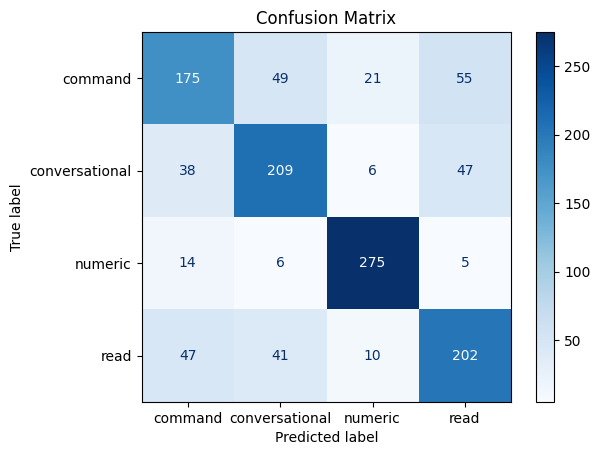

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Predictions
# -----------------------------
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

macro_f1 = f1

# -----------------------------
# ROC-AUC
# -----------------------------
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# -----------------------------
# Equal Error Rate (EER)
# -----------------------------
eer_list = []

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    fnr = 1 - tpr

    idx = np.nanargmin(np.abs(fpr - fnr))

    eer = (fpr[idx] + fnr[idx]) / 2

    eer_list.append(eer)

eer = np.mean(eer_list)

# -----------------------------
# Print Metrics
# -----------------------------
print("="*45)
print("Best Model Evaluation")
print("="*45)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision:.4f}")
print(f"Recall (Macro)     : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"Equal Error Rate   : {eer:.4f}")

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()